# Agrisubsidy Random Forest + SHAP

This notebook trains a Random Forest classifier using the Agrisubsidy dataset and generates model-based explanations with SHAP.

**Expected Excel columns:**
- Subsidy Type
- Farm Size (ha)
- Average Yield (tons/ha)
- Crop Yield (tons/ha)
- Average Selling Price (₱/kg)
- Feedback Score
- Subsidy Received
- Pest
- Calamity
- Effectiveness Label


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [22]:
# Load dataset
file_path = "datasets/subsidy_dataset2_initial.xlsx"
df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())

Dataset loaded successfully!
Rows: 789
Columns: 10


,Subsidy Type,Farm Size (ha),Average Yield (tons/ha),Crop Yield (tons/ha),Average Selling Price (₱/kg),Feedback Score,Subsidy Received,Pest,Calamity,Effectiveness Label
0,Rice/Palay,0.1294,4.3,4.54,21.29,4.4,No,Aphids,Extreme Heat,Moderately Effective
1,Rice/Palay,1.0000,4.2,4.98,23.29,4.7,Yes,"Leaf Folder, Rice Bug","Pest Outbreak, Flood",Effective
2,Rice/Palay,2.0000,4.2,4.73,22.29,4.9,No,NaN,"Flood, Drought",Effective
3,Rice/Palay,0.0401,4.2,4.56,22.69,4.8,Yes,Rice Bug,Typhoon,Effective
4,Rice/Palay,0.1932,4.3,5.05,22.69,4.7,Yes,"Leaf Folder, Aphids","Drought, Pest Outbreak",Effective


In [23]:
# Inspect dataset
print("COLUMN NAMES")
for column in df.columns:
    print(column)

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

COLUMN NAMES
Subsidy Type
Farm Size (ha)
Average Yield (tons/ha)
Crop Yield (tons/ha)
Average Selling Price (₱/kg)
Feedback Score
Subsidy Received
Pest
Calamity
Effectiveness Label

DATA TYPES
Subsidy Type                        str
Farm Size (ha)                  float64
Average Yield (tons/ha)         float64
Crop Yield (tons/ha)            float64
Average Selling Price (₱/kg)    float64
Feedback Score                  float64
Subsidy Received                    str
Pest                                str
Calamity                            str
Effectiveness Label                 str
dtype: object

MISSING VALUES
Subsidy Type                      0
Farm Size (ha)                    0
Average Yield (tons/ha)           0
Crop Yield (tons/ha)              0
Average Selling Price (₱/kg)      0
Feedback Score                    0
Subsidy Received                  0
Pest                            113
Calamity                        132
Effectiveness Label               0
dtype: int64

DUP

In [24]:
# Clean column names and empty rows
df.columns = df.columns.astype(str).str.strip()
df = df.dropna(how="all")

features = [
    "Subsidy Type",
    "Farm Size (ha)",
    "Average Yield (tons/ha)",
    "Crop Yield (tons/ha)",
    "Average Selling Price (₱/kg)",
    "Feedback Score",
    "Subsidy Received",
    "Pest",
    "Calamity"
]

target = "Effectiveness Label"

missing_columns = [c for c in features + [target] if c not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

X = df[features].copy()
y = df[target].copy()

print("All required columns are available.")

All required columns are available.


In [25]:
# Define feature types
numeric_features = [
    "Farm Size (ha)",
    "Average Yield (tons/ha)",
    "Crop Yield (tons/ha)",
    "Average Selling Price (₱/kg)",
    "Feedback Score"
]

categorical_features = [
    "Subsidy Type",
    "Subsidy Received",
    "Pest",
    "Calamity"
]

# Convert numeric columns
for column in numeric_features:
    X[column] = pd.to_numeric(X[column], errors="coerce")

# Clean categorical columns
for column in categorical_features:
    X[column] = X[column].astype("string").str.strip().fillna("Unknown")

# Clean target and remove invalid target rows
y = y.astype("string").str.strip()
valid = y.notna() & ~y.isin(["", "nan", "None", "<NA>"])

X = X.loc[valid].copy()
y = y.loc[valid].copy()

# Fill missing numeric values with median
for column in numeric_features:
    X[column] = X[column].fillna(X[column].median())

print("Remaining records:", len(y))
print("\nClass distribution:")
print(y.value_counts())

Remaining records: 789

Class distribution:


Effectiveness Label
Moderately Effective    263
Effective               263
Not Effective           263
Name: count, dtype: Int64


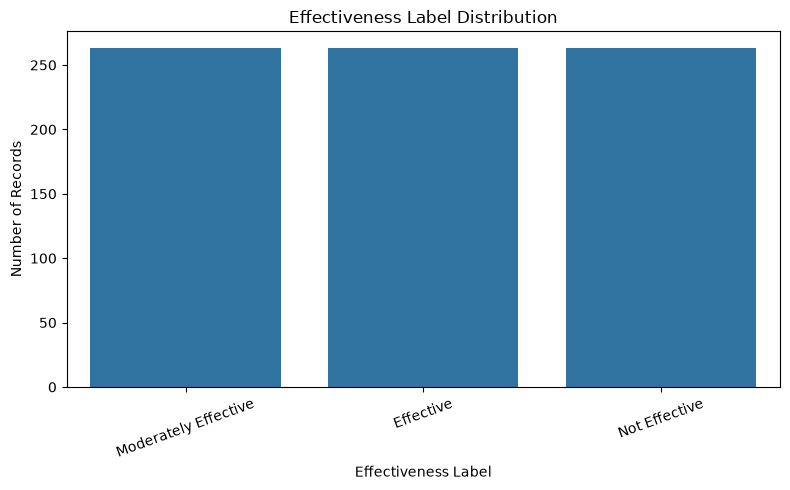

,Farm Size (ha),Average Yield (tons/ha),Crop Yield (tons/ha),Average Selling Price (₱/kg),Feedback Score
count,789.000000,789.000000,789.000000,789.000000,789.000000
mean,1.316417,4.257161,4.577060,22.315982,3.950444
std,1.193675,0.049516,0.299775,1.315264,0.821655
min,0.027400,4.200000,3.630000,19.790000,1.100000
25%,0.698700,4.200000,4.370000,21.290000,3.500000
50%,1.000000,4.300000,4.600000,22.290000,4.100000
75%,1.598400,4.300000,4.790000,23.290000,4.600000
max,19.408700,4.300000,5.300000,24.690000,5.000000


In [26]:
# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y, order=y.value_counts().index)
plt.title("Effectiveness Label Distribution")
plt.xlabel("Effectiveness Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(X[numeric_features].describe())

In [27]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 631
Testing records: 158


In [28]:
# One-hot encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Transformed feature count:", len(feature_names))

Transformed feature count: 64


In [29]:
# Create and train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt",
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train_transformed, y_train)
print("Training completed!")

Training Random Forest...
Training completed!


In [30]:
# Evaluate model
y_pred = rf_model.predict(X_test_transformed)
y_probability = rf_model.predict_proba(X_test_transformed)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")

print("\nClassification Report")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 76.58%
Precision: 76.67%
Recall   : 76.58%
F1 Score : 76.30%

Classification Report
                      precision    recall  f1-score   support

           Effective       0.84      0.73      0.78        52
Moderately Effective       0.67      0.64      0.65        53
       Not Effective       0.79      0.92      0.85        53

            accuracy                           0.77       158
           macro avg       0.77      0.77      0.76       158
        weighted avg       0.77      0.77      0.76       158



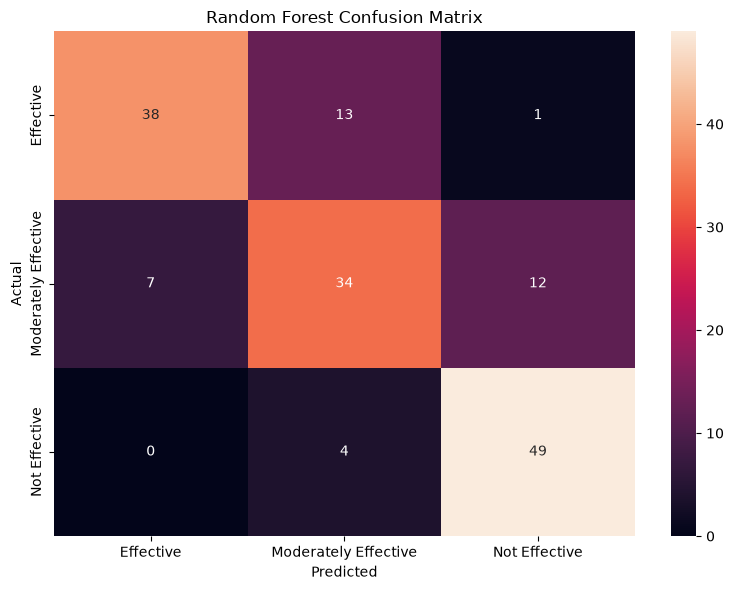

In [31]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

,Feature,Importance
61,remainder__Crop Yield (tons/ha),0.307478
63,remainder__Feedback Score,0.245921
59,remainder__Farm Size (ha),0.086973
62,remainder__Average Selling Price (₱/kg),0.064488
60,remainder__Average Yield (tons/ha),0.021940
...,...,...
4,"categorical__Pest_Aphids, Armyworm",0.000939
16,"categorical__Pest_Brown Planthopper, Aphids",0.000896
23,"categorical__Pest_Leaf Folder, Armyworm",0.000743
29,"categorical__Pest_Rice Bug, Armyworm",0.000553


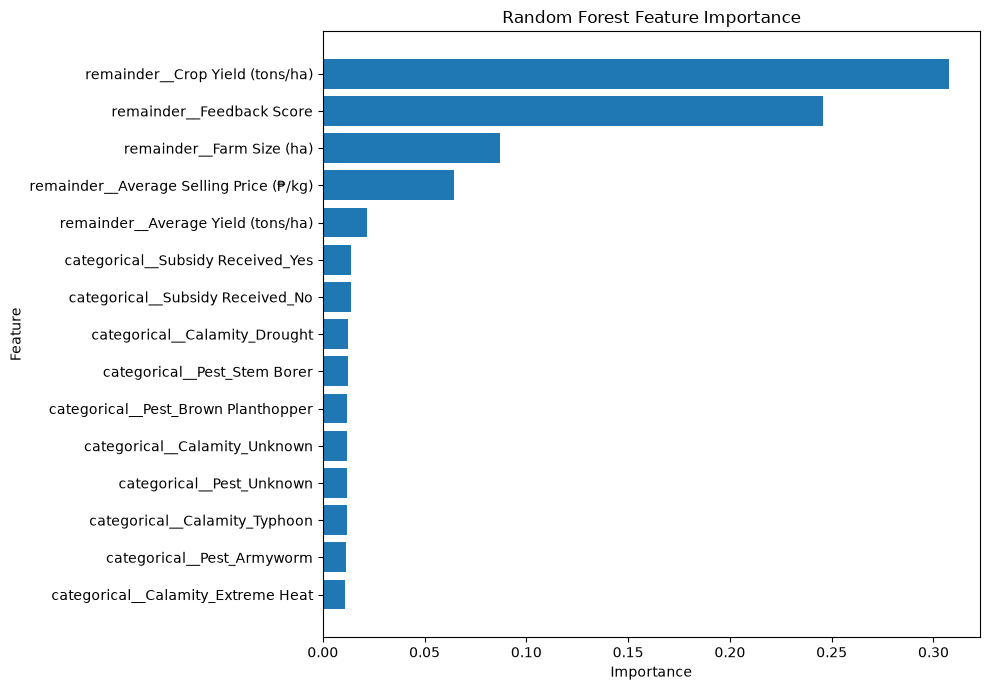

In [32]:
# Feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df)

top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [33]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)
print("SHAP explainer created.")

SHAP explainer created.


In [34]:
# Example new farmer record
new_farmer = pd.DataFrame([{
    "Subsidy Type": "Seed",
    "Farm Size (ha)": 2.5,
    "Average Yield (tons/ha)": 4.0,
    "Crop Yield (tons/ha)": 4.8,
    "Average Selling Price (₱/kg)": 25,
    "Feedback Score": 5,
    "Subsidy Received": "Yes",
    "Pest": "No",
    "Calamity": "No"
}])

display(new_farmer)

new_farmer_transformed = preprocessor.transform(new_farmer)

,Subsidy Type,Farm Size (ha),Average Yield (tons/ha),Crop Yield (tons/ha),Average Selling Price (₱/kg),Feedback Score,Subsidy Received,Pest,Calamity
0,Seed,2.5,4.0,4.8,25,5,Yes,No,No


In [35]:
# Predict new farmer
prediction = rf_model.predict(new_farmer_transformed)[0]
probabilities = rf_model.predict_proba(new_farmer_transformed)[0]
classes = rf_model.classes_

probability_dict = dict(zip(classes, probabilities))
confidence = probability_dict[prediction] * 100

print("=" * 60)
print("AGRISUBSIDY EFFECTIVENESS PREDICTION")
print("=" * 60)
print(f"\nPrediction: {prediction}")
print(f"Confidence: {confidence:.2f}%")

print("\nClass Probabilities:")
for label, probability in probability_dict.items():
    print(f"{label}: {probability * 100:.2f}%")

AGRISUBSIDY EFFECTIVENESS PREDICTION

Prediction: Effective
Confidence: 84.67%

Class Probabilities:
Effective: 84.67%
Moderately Effective: 15.00%
Not Effective: 0.33%


In [36]:
# SHAP values for the new farmer
new_shap_values = explainer.shap_values(new_farmer_transformed)
shap_array = np.asarray(new_shap_values)

predicted_class_index = list(classes).index(prediction)

print("SHAP output shape:", shap_array.shape)

if shap_array.ndim == 3:
    class_shap_values = shap_array[0, :, predicted_class_index]
elif shap_array.ndim == 2:
    class_shap_values = shap_array[0]
else:
    raise ValueError(f"Unexpected SHAP output shape: {shap_array.shape}")

SHAP output shape: (1, 64, 3)


In [37]:
# Create per-prediction feature contribution table
explanation_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": class_shap_values,
    "Absolute Impact": np.abs(class_shap_values)
}).sort_values("Absolute Impact", ascending=False)

display(explanation_df)

,Feature,SHAP Value,Absolute Impact
63,remainder__Feedback Score,0.279785,0.279785
61,remainder__Crop Yield (tons/ha),0.168826,0.168826
60,remainder__Average Yield (tons/ha),0.048977,0.048977
62,remainder__Average Selling Price (₱/kg),-0.041657,0.041657
54,categorical__Calamity_Typhoon,0.013202,0.013202
...,...,...,...
29,"categorical__Pest_Rice Bug, Armyworm",-0.000062,0.000062
10,"categorical__Pest_Armyworm, Aphids",0.000059,0.000059
45,"categorical__Calamity_Extreme Heat, Pest Outbreak",0.000056,0.000056
26,"categorical__Pest_Leaf Folder, Stem Borer",0.000051,0.000051


In [38]:
# Generate a dynamic explanation from SHAP contributions
def generate_explanation(prediction, confidence, explanation_df):
    positive = explanation_df[explanation_df["SHAP Value"] > 0].head(3)
    negative = explanation_df[explanation_df["SHAP Value"] < 0].head(3)

    parts = [
        f"The model classified the subsidy as {prediction} "
        f"with {confidence:.2f}% confidence."
    ]

    if len(positive) > 0:
        positive_names = [
            str(f).replace("categorical__", "").replace("remainder__", "")
            for f in positive["Feature"]
        ]
        parts.append(
            "The strongest factors supporting the prediction were "
            + ", ".join(positive_names) + "."
        )

    if len(negative) > 0:
        negative_names = [
            str(f).replace("categorical__", "").replace("remainder__", "")
            for f in negative["Feature"]
        ]
        parts.append(
            "The factors that worked against the prediction were "
            + ", ".join(negative_names) + "."
        )

    return " ".join(parts)

message = generate_explanation(
    prediction,
    confidence,
    explanation_df
)

print("=" * 70)
print("MODEL-BASED EXPLANATION")
print("=" * 70)
print()
print(message)

MODEL-BASED EXPLANATION

The model classified the subsidy as Effective with 84.67% confidence. The strongest factors supporting the prediction were Feedback Score, Crop Yield (tons/ha), Average Yield (tons/ha). The factors that worked against the prediction were Average Selling Price (₱/kg), Calamity_Pest Outbreak, Calamity_Drought.


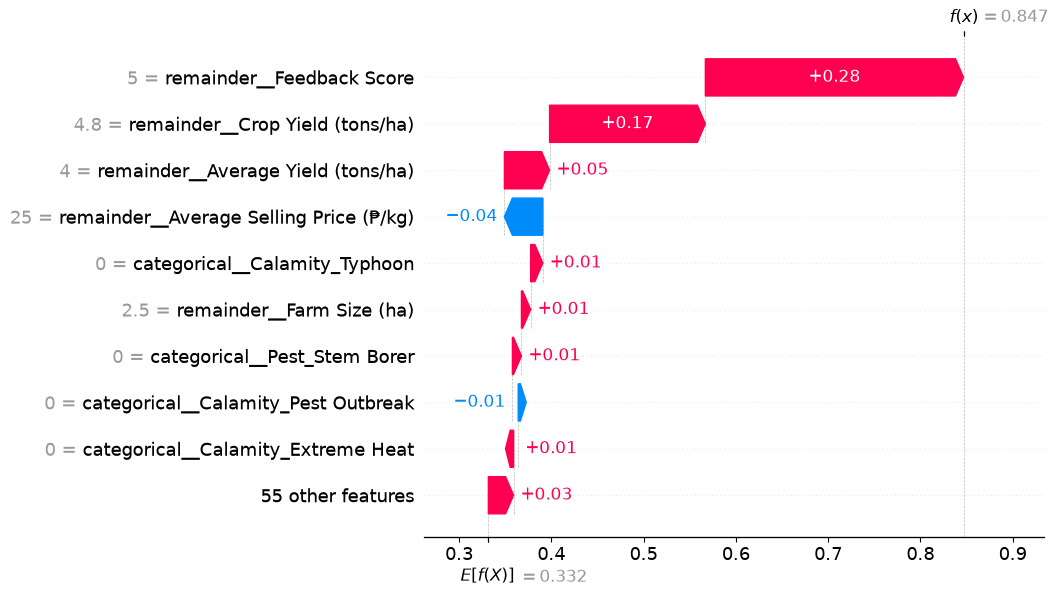

In [39]:
# SHAP waterfall plot
# This visually shows the strongest contributions for this prediction.

expected_value = explainer.expected_value
if np.ndim(expected_value) > 0:
    base_value = expected_value[predicted_class_index]
else:
    base_value = expected_value

shap_explanation = shap.Explanation(
    values=class_shap_values,
    base_values=base_value,
    data=new_farmer_transformed[0],
    feature_names=feature_names
)

shap.plots.waterfall(shap_explanation, max_display=10)

In [40]:
# Save trained model and preprocessing object
joblib.dump(rf_model, "agrisubsidy_random_forest.pkl")
joblib.dump(preprocessor, "agrisubsidy_preprocessor.pkl")

# Save feature importance and explanation
importance_df.to_excel(
    "agrisubsidy_feature_importance.xlsx",
    index=False
)

explanation_df.to_excel(
    "agrisubsidy_shap_explanation.xlsx",
    index=False
)

# Save test predictions
test_results = X_test.copy()
test_results["Actual Effectiveness"] = y_test.values
test_results["Predicted Effectiveness"] = y_pred
test_results["Prediction Confidence (%)"] = np.max(
    y_probability,
    axis=1
) * 100

test_results.to_excel(
    "agrisubsidy_test_predictions.xlsx",
    index=False
)

print("All model files and results saved successfully.")

All model files and results saved successfully.
